## Mount the google drive

## Unzip the dataset

In [ ]:
DATA_PATH = '02 - CNN-Cards\Datasets'
DRIVE_PATH = '02 - CNN-Cards'

## Import libraries

In [2]:
import tensorflow as tf
from vit_keras import vit
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Global variables
SIZE = 224    # Dimensions of the images
CLASSES = 53  # Number of categories
EPOCHS = 75
PATIENCE_ES = 20

path_models = DRIVE_PATH+r'Models'

In [3]:
print(tf.__version__)

print(tf.test.gpu_device_name())

if tf.test.is_built_with_gpu_support():
    print('Se detectó una GPU')
else:
    print('No se detectó una GPU')

2.17.1

No se detectó una GPU


In [4]:
!nvidia-smi

Thu Nov 27 13:30:47 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.44                 Driver Version: 573.44         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 2000 Ada Gene...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   53C    P3             10W /   43W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load pre-trained models

In [5]:
# Download pre-trained models without the Top
MobileNet = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(SIZE,SIZE,3))
vitB16 = vit.vit_b16(image_size= SIZE, include_top=False, pretrained_top=False, pretrained=True)

vitB16.trainable = False
MobileNet.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

347502902/347502902 ━━━━━━━━━━━━━━━━━━━━ 132s 0us/step


c:\Users\enriq\Desktop\Master\Deep Learning\Clases Borro\Práctica\02 - CNN-Cards\venv_dl\Lib\site-packages\vit_keras\utils.py:85: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


In [6]:
# Summary of the model
MobileNet.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

API Sequential: Una forma sencilla y lineal de apilar capas.

Limitaciones:

*   No permite modelos con múltiples entradas o salidas
*  No admite capas compartidas o conexiones no lineales
*   No es adecuada para arquitecturas donde se necesitan saltos o conexiones entre capas no adyacentes.


API Funcional: Una forma más flexible que permite construir modelos complejos con arquitecturas personalizadas.

## Build model in Sequential API

In [7]:
# Build models based on the pre-trained with the Sequential API

# creation as a list of layers
mn_sq = tf.keras.Sequential([
    MobileNet,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(CLASSES, activation='softmax')
                                ])
transformer_sq = tf.keras.Sequential([
    vitB16,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(CLASSES, activation='softmax')
                                ])
# Creation by adding layers
model_sq = tf.keras.Sequential()
model_sq.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(224,224,3)))
model_sq.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model_sq.add(tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_sq.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model_sq.add(tf.keras.layers.Flatten())
model_sq.add(tf.keras.layers.Dense(128, activation='relu'))
model_sq.add(tf.keras.layers.Dense(64, activation='relu'))
model_sq.add(tf.keras.layers.Dense(CLASSES, activation='softmax'))

c:\Users\enriq\Desktop\Master\Deep Learning\Clases Borro\Práctica\02 - CNN-Cards\venv_dl\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Summary of the model
mn_sq.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,028,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 53)             │         3,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,297,973 (39.28 MB)

 Trainable params: 8,039,989 (30.67 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Summary of the model
transformer_sq.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vit-b16 (Functional)            │ (None, 768)            │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 53)             │         3,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,908,789 (327.72 MB)

 Trainable params: 110,133 (430.21 KB)

 Non-trainable params: 85,798,656 (327.30 MB)

In [10]:
# Summary of the model
model_sq.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 53)             │         3,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,919,093 (91.24 MB)

 Trainable params: 23,919,093 (91.24 MB)

 Non-trainable params: 0 (0.00 B)

## Build model in Functional API

In [11]:
# Build models based on the pre-trained with the Functional API

inputy = tf.keras.layers.Input(shape=(SIZE,SIZE,3))
y = MobileNet(inputy)
y = tf.keras.layers.Flatten()(y)
y = tf.keras.layers.Dense(128, activation='relu')(y)
y = tf.keras.layers.Dense(64, activation='relu')(y)
outputy = tf.keras.layers.Dense(CLASSES, activation='softmax')(y)

mn_fc = tf.keras.Model(inputs=inputy, outputs=outputy)

#########################################################################################

input = tf.keras.layers.Input(shape=(SIZE,SIZE,3))  # Declare input layer
x = vitB16(input)
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
output = tf.keras.layers.Dense(CLASSES, activation='softmax')(x)

transformer_fc = tf.keras.Model(inputs=input, outputs=output)  # Build the model

#########################################################################################

inputc = tf.keras.layers.Input(shape=(SIZE,SIZE,3))
y = tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(224,224,3))(inputc)
y = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(y)
y = tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu')(y)
y = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(y)
y = tf.keras.layers.Flatten()(y)
y = tf.keras.layers.Dense(128, activation='relu')(y)
y = tf.keras.layers.Dense(64, activation='relu')(y)
outputc = tf.keras.layers.Dense(CLASSES, activation='softmax')(y)

model_fc = tf.keras.Model(inputs=inputc, outputs=outputc)

In [12]:
# Summary of the model
mn_fc.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     8,028,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 53)             │         3,445 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,297,973 (39.28 MB)

 Trainable params: 8,039,989 (30.67 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compare models

In [13]:
# Number of parameters comparision
# Convolutional transfer learning
trainable_params_cfc = np.sum([np.prod(variable.shape) for variable in mn_fc.trainable_variables])
non_trainable_params_cfc = np.sum([np.prod(variable.shape) for variable in mn_fc.non_trainable_variables])

trainable_params_csq = np.sum([np.prod(variable.shape) for variable in mn_sq.trainable_variables])
non_trainable_params_csq = np.sum([np.prod(variable.shape) for variable in mn_sq.non_trainable_variables])

if (trainable_params_cfc == trainable_params_csq) and (non_trainable_params_cfc==non_trainable_params_csq):
  print('MobileNet model OK')

# Transformer architecture
trainable_params_tfc = np.sum([np.prod(variable.shape) for variable in transformer_fc.trainable_variables])
non_trainable_params_tfc = np.sum([np.prod(variable.shape) for variable in transformer_fc.non_trainable_variables])

trainable_params_tsq = np.sum([np.prod(variable.shape) for variable in transformer_sq.trainable_variables])
non_trainable_params_tsq = np.sum([np.prod(variable.shape) for variable in transformer_sq.non_trainable_variables])

if (trainable_params_tfc == trainable_params_tsq) and (non_trainable_params_tfc==non_trainable_params_tsq):
  print('Transformer model OK')

# Custom convolutional model
trainable_params_customfc = np.sum([np.prod(variable.shape) for variable in model_fc.trainable_variables])
non_trainable_params_customfc = np.sum([np.prod(variable.shape) for variable in model_fc.non_trainable_variables])

trainable_params_customsq = np.sum([np.prod(variable.shape) for variable in model_sq.trainable_variables])
non_trainable_params_customsq = np.sum([np.prod(variable.shape) for variable in model_sq.non_trainable_variables])

if (trainable_params_customfc == trainable_params_customsq) and (non_trainable_params_customfc==non_trainable_params_customsq):
  print('Convolutional model OK')

MobileNet model OK
Transformer model OK
Convolutional model OK


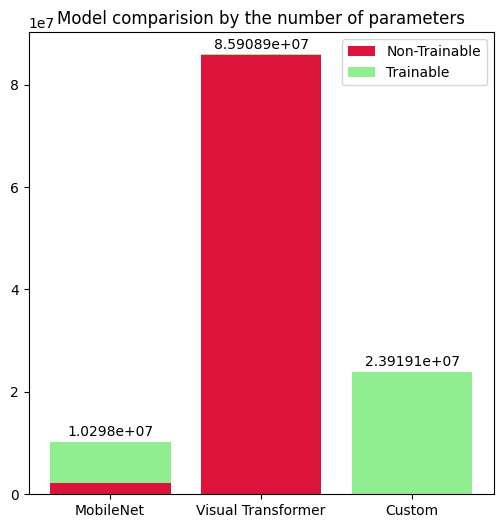

In [14]:
fig = plt.figure(figsize=(6,6))

axis_x = ['MobileNet', 'Visual Transformer', 'Custom']

ax = plt.subplot(1, 1, 1)
ax.bar(axis_x, [non_trainable_params_cfc, non_trainable_params_tfc, non_trainable_params_customfc], color='crimson', label='Non-Trainable')
b = ax.bar(axis_x, [trainable_params_cfc, trainable_params_tfc, trainable_params_customfc], bottom= [non_trainable_params_cfc, non_trainable_params_tfc, non_trainable_params_customfc], color='lightgreen', label='Trainable')
ax.bar_label(b, padding= 2)
ax.set_title('Model comparision by the number of parameters')
ax.legend(loc = 'upper right')
plt.show()

Despite the overall size of the model, the Transformer-based architecture has a very low number of trainable parameters.

## Load data

### Image data generator

In [15]:
# Image generator from TensorFlow (https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator)

train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255,
                                                                  rotation_range=10,
                                                                  horizontal_flip=True)

valid_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)

### Flow from directory method

In [19]:
# Build the datasets with flow from directory method from ImageDataGenerator object

train_path = DATA_PATH + '\train'
valid_path = DATA_PATH + '\valid'
test_path = DATA_PATH + '\test'

# Path to the directory
# Define sizes
# Declare classes as categorical
# Batch size = 16
# Train dataset should always have shuffle
train_dataset_ffd = train_generator.flow_from_directory(
    train_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= True
                                                        )

# Valid and Test dataset don't need to be shuffled
valid_dataset_ffd = valid_generator.flow_from_directory(
    valid_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

test_dataset_ffd = test_generator.flow_from_directory(
    test_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

OSError: [WinError 123] El nombre de archivo, el nombre de directorio o la sintaxis de la etiqueta del volumen no son correctos: 'C:\\Users\\enriq\\Desktop\\Master\\Deep Learning\\Clases Borro\\Práctica\\02 - CNN-Cards\\02 - CNN-Cards\\Datasets\train'

## Train models

### MobileNet

In [ ]:
# Callbacks definitions for training
# Save the best model at the end of each epoch (if is better than the saved one)
# Stop training if the model is not improving after 20 epochs

name = 'MobileNet'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(path_models, name + '.h5'),
    monitor= 'val_accuracy',
    verbose= 0,
    save_best_only= True,
    save_weights_only= False,
    mode= 'max',
    save_freq= 'epoch')

stop = tf.keras.callbacks.EarlyStopping(
    monitor= 'val_accuracy',
    min_delta= 0.01,
    patience= PATIENCE_ES,
    verbose = 0,
    mode= 'max',
    baseline= None,
    restore_best_weights= True)

In [ ]:
# Model compilation
mn_sq.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
def plot_and_save(h, dir, name):

  history = pd.DataFrame(h.history)

  history['epoch'] = list(range(0,len(history.index)))

  history.to_csv(os.path.join(dir, name+'.csv'), header=True, index=False)

  # Plot history: CE
  plt.figure()
  plt.plot(history['epoch'], history['loss'], label='Loss (training data)')
  plt.plot(history['epoch'], history['val_loss'], label='Loss (validation data)')
  plt.title('Loss')
  plt.ylabel('CE')
  plt.xlabel('Nº epoch')
  plt.legend(loc="upper left")
  plt.show()

  # Plot history: Accuracy
  plt.figure()
  plt.plot(history['epoch'], history['accuracy'], label='Accuracy (training data)')
  plt.plot(history['epoch'], history['val_accuracy'], label='Accuracy (validation data)')
  plt.title('Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Nº epoch')
  plt.legend(loc="upper left")
  plt.show()

In [ ]:
EPOCHS = 25
h = mn_sq.fit(train_dataset_ffd, validation_data=valid_dataset_ffd, epochs=EPOCHS, callbacks=[checkpoint, stop])

In [ ]:
plot_and_save(h, path_csv, name)

This model is overfitted, data augmentation in training data is required

### Visual Transformer

In [ ]:
# Callbacks definitions for training
# Save the best model at the end of each epoch (if is better than the saved one)
# Stop training if the model is not improving after 20 epochs

name = 'ViT_B16'

checkpointv = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(path_models, name + '.h5'),
    monitor= 'val_accuracy',
    verbose= 0,
    save_best_only= True,
    save_weights_only= False,
    mode= 'max',
    save_freq= 'epoch'
                                                )

stopv = tf.keras.callbacks.EarlyStopping(
    monitor= 'val_accuracy',
    min_delta= 0.01,
    patience= PATIENCE_ES,
    verbose = 0,
    mode= 'max',
    baseline= None,
    restore_best_weights= True
                                                )

In [ ]:
# Model compilation
transformer_sq.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
h = transformer_sq.fit(train_dataset_ffd, validation_data=valid_dataset_ffd, epochs=EPOCHS, callbacks=[checkpointv, stopv])

In [ ]:
plot_and_save(h, path_csv, name)

This model is overfitted, and also needs more trainable parameters

### Custom

In [ ]:
# Compile the model
model_sq.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Callbacks definitions for training
# Save the best model at the end of each epoch (if is better than the saved one)
# Stop training if the model is not improving after 20 epochs

name = 'Custom'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(path_models, name + '.h5'),
    monitor= 'val_accuracy',
    verbose= 0,
    save_best_only= True,
    save_weights_only= False,
    mode= 'max',
    save_freq= 'epoch'
                                                )

stop = tf.keras.callbacks.EarlyStopping(
    monitor= 'val_accuracy',
    min_delta= 0.01,
    patience= PATIENCE_ES,
    verbose = 0,
    mode= 'max',
    baseline= None,
    restore_best_weights= True
                                                )

h = model_sq.fit(train_dataset_ffd, validation_data=valid_dataset_ffd, epochs=EPOCHS, callbacks=[checkpoint, stop])

In [ ]:
plot_and_save(h, path_csv, name)

This model is overfitted

## Fine tuning train

### MobileNet, data augmentation in training data is implemented, number of trainable weights is higher

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255,
                                                                  rotation_range=15,
                                                                  horizontal_flip=True,
                                                                  vertical_flip=True,
                                                                  zoom_range=0.1,
                                                                  fill_mode='reflect')


valid_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)

train_path = DATA_PATH + 'train'
valid_path = DATA_PATH + 'valid'
test_path = DATA_PATH + 'test'

# Path to the directory
# Define sizes
# Declare classes as categorical
# Batch size = 16
# Train dataset should always have shuffle
train_dataset_ffd = train_generator.flow_from_directory(
    train_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= True
                                                        )

# Valid and Test dataset don't need to be shuffled
valid_dataset_ffd = valid_generator.flow_from_directory(
    valid_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

test_dataset_ffd = test_generator.flow_from_directory(
    test_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

In [ ]:
name = 'MobileNet_2'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(path_models, name + '.h5'),
    monitor= 'val_accuracy',
    verbose= 0,
    save_best_only= True,
    save_weights_only= False,
    mode= 'max',
    save_freq= 'epoch'
                                                )

stop = tf.keras.callbacks.EarlyStopping(
    monitor= 'val_accuracy',
    min_delta= 0.001,
    patience= PATIENCE_ES,
    verbose = 0,
    mode= 'max',
    baseline= None,
    restore_best_weights= True
                                                )

In [ ]:
mn_train_1 = tf.keras.models.load_model(DATA_PATH+'Models/MobileNet.h5')
weights = mn_train_1.get_weights()

base_net = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(SIZE,SIZE,3))

# by default, layers are trainable
# MobileNet has 154 layers
# Freezing 130, rougthly 60% trainable parameters
for layer in base_net.layers[:130]:
    layer.trainable = False

mn_ft = tf.keras.Sequential([
    base_net,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(CLASSES, activation='softmax')])

In [ ]:
EPOCHS=100
mn_ft.set_weights(weights)

mn_ft.compile(optimizer= 'adam', loss='categorical_crossentropy', metrics=['accuracy'])
h = mn_ft.fit(train_dataset_ffd, validation_data=valid_dataset_ffd, epochs=EPOCHS, callbacks=[checkpoint, stop])

plot_and_save(h, path_csv, name)

### ViT, data augmentation in training is implemented, number of trainable weights is higher

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255,
                                                                  rotation_range=20,
                                                                  horizontal_flip=True,
                                                                  vertical_flip=True,
                                                                  zoom_range=0.1,
                                                                  fill_mode='reflect')


valid_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)

train_path = DATA_PATH + 'train'
valid_path = DATA_PATH + 'valid'
test_path = DATA_PATH + 'test'

# Path to the directory
# Define sizes
# Declare classes as categorical
# Batch size = 16
# Train dataset should always have shuffle
train_dataset_ffd = train_generator.flow_from_directory(
    train_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= True
                                                        )

# Valid and Test dataset don't need to be shuffled
valid_dataset_ffd = valid_generator.flow_from_directory(
    valid_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

test_dataset_ffd = test_generator.flow_from_directory(
    test_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

In [ ]:
name = 'ViT_B16_2'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(path_models, name + '.h5'),
    monitor= 'val_accuracy',
    verbose= 0,
    save_best_only= True,
    save_weights_only= False,
    mode= 'max',
    save_freq= 'epoch'
                                                )

stop = tf.keras.callbacks.EarlyStopping(
    monitor= 'val_accuracy',
    min_delta= 0.001,
    patience= PATIENCE_ES,
    verbose = 0,
    mode= 'max',
    baseline= None,
    restore_best_weights= True
                                                )

In [ ]:
transformer_train_1 = tf.keras.models.load_model(DATA_PATH+'Models/ViT_B16.h5')
weights = transformer_train_1.get_weights()

# the pretrained is similar to weigths="imagenet"
base_net = vit.vit_b16(image_size= SIZE, include_top=False, pretrained_top=False, pretrained=True)

# by default, layers are trainable
# ViT has 19 layers
# Freezing 10, rougthly 60% trainable parameters
for layer in base_net.layers[:10]:
    layer.trainable = False

transformer_ft = tf.keras.Sequential([
    base_net,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(CLASSES, activation='softmax')])

In [ ]:
transformer_ft.set_weights(weights)

transformer_ft.compile(optimizer= 'adam', loss='categorical_crossentropy', metrics=['accuracy'])
h = transformer_ft.fit(train_dataset_ffd, validation_data=valid_dataset_ffd, epochs=EPOCHS, callbacks=[checkpoint, stop])

plot_and_save(h, path_csv, name)

### Custom, data augmentation in training is implemented

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255,
                                                                  rotation_range=15,
                                                                  horizontal_flip=True,
                                                                  vertical_flip=True,
                                                                  zoom_range=0.1,
                                                                  fill_mode='reflect')


valid_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)

train_path = DATA_PATH + 'train'
valid_path = DATA_PATH + 'valid'
test_path = DATA_PATH + 'test'

# Path to the directory
# Define sizes
# Declare classes as categorical
# Batch size = 16
# Train dataset should always have shuffle
train_dataset_ffd = train_generator.flow_from_directory(
    train_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= True
                                                        )

# Valid and Test dataset don't need to be shuffled
valid_dataset_ffd = valid_generator.flow_from_directory(
    valid_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

test_dataset_ffd = test_generator.flow_from_directory(
    test_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

In [ ]:
name = 'Custom_2'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(path_models, name + '.h5'),
    monitor= 'val_accuracy',
    verbose= 0,
    save_best_only= True,
    save_weights_only= False,
    mode= 'max',
    save_freq= 'epoch'
                                                )

stop = tf.keras.callbacks.EarlyStopping(
    monitor= 'val_accuracy',
    min_delta= 0.001,
    patience= PATIENCE_ES,
    verbose = 0,
    mode= 'max',
    baseline= None,
    restore_best_weights= True
                                                )

In [ ]:
model_ft = tf.keras.models.load_model('Models/Custom.h5')

In [ ]:
model_ft.compile(optimizer= 'adam', loss='categorical_crossentropy', metrics=['accuracy'])
h = model_ft.fit(train_dataset_ffd, validation_data=valid_dataset_ffd, epochs=EPOCHS, callbacks=[checkpoint, stop])

plot_and_save(h, path_csv, name)

#### STILL OVERFITTED, RE-TRAIN WITH MORE DATA AUGMENTATION

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255,
                                                                  rotation_range=10,
                                                                  horizontal_flip=True,
                                                                  vertical_flip=True,
                                                                  zoom_range=0.1,
                                                                  fill_mode='reflect',
                                                                  width_shift_range=0.1,
                                                                  shear_range=0.1,
                                                                  brightness_range=(0.95,1.05))


valid_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale= 1.0/255)

train_path = DATA_PATH + 'train'
valid_path = DATA_PATH + 'valid'
test_path = DATA_PATH + 'test'

# Path to the directory
# Define sizes
# Declare classes as categorical
# Batch size = 16
# Train dataset should always have shuffle
train_dataset_ffd = train_generator.flow_from_directory(
    train_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= True
                                                        )

# Valid and Test dataset don't need to be shuffled
valid_dataset_ffd = valid_generator.flow_from_directory(
    valid_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                        )

test_dataset_ffd = test_generator.flow_from_directory(
    test_path,
    target_size= (SIZE,SIZE),
    class_mode= 'categorical',
    batch_size= 64,
    shuffle= False
                                                    )

In [ ]:
name = 'Custom_3'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(path_models, name + '.h5'),
    monitor= 'val_accuracy',
    verbose= 0,
    save_best_only= True,
    save_weights_only= False,
    mode= 'max',
    save_freq= 'epoch'
                                                )

stop = tf.keras.callbacks.EarlyStopping(
    monitor= 'val_accuracy',
    min_delta= 0.001,
    patience= PATIENCE_ES,
    verbose = 0,
    mode= 'max',
    baseline= None,
    restore_best_weights= True
                                                )

In [ ]:
model_ft2 = tf.keras.models.load_model('Models/Custom_2.h5')
model_ft2.compile(optimizer= 'adam', loss='categorical_crossentropy', metrics=['accuracy'])
h = model_ft2.fit(train_dataset_ffd, validation_data=valid_dataset_ffd, epochs=EPOCHS, callbacks=[checkpoint, stop])

plot_and_save(h, path_csv, name)

## Evaluation of fine tuning

In [ ]:
custom2 = tf.keras.models.load_model('Cards/Custom_2.h5')
custom3 = tf.keras.models.load_model('Models/Custom_3.h5')
transf2 = tf.keras.models.load_model('Models/ViT_B16_2.h5')
conv2 = tf.keras.models.load_model('Models/MobileNet_2.h5')

In [ ]:
_, conv_acc2 = conv2.evaluate(test_dataset_ffd)
_, transf_acc2 = transf2.evaluate(test_dataset_ffd)
_, custom_acc2 = custom2.evaluate(test_dataset_ffd)
_, custom_acc3 = custom3.evaluate(test_dataset_ffd)

In [ ]:
fig = plt.figure(figsize=(6,6))

axis_x = ['MobileNet', 'Visual Transformer', 'Custom']

b = plt.bar(axis_x, [conv_acc2, transf_acc2, custom_acc3], color='crimson', label='Accuracy')
plt.bar_label(b, padding= 2)
plt.title('Model comparision by accuracy in test data')
plt.legend(loc = 'lower right')
plt.show()

### Classification report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def show_report(model, dataframe):

  labels = dataframe.class_indices

  true_labels = dataframe.labels
  pred_labels = model.predict(dataframe, verbose=0).argmax(axis=1)

  keys_array = np.array(list(labels.keys()))

  true_text = [keys_array[value] for value in true_labels]
  pred_text = [keys_array[value] for value in pred_labels]

  print(classification_report(true_text, pred_text))


def show_matrix(model, dataframe):

  labels = dataframe.class_indices

  true_labels = dataframe.labels
  pred_labels = model.predict(dataframe, verbose=0).argmax(axis=1)

  keys_array = np.array(list(labels.keys()))

  true_text = [keys_array[value] for value in true_labels]
  pred_text = [keys_array[value] for value in pred_labels]

  cf = confusion_matrix(true_text, pred_text, labels= keys_array)

  fig, ax = plt.subplots(figsize=(12,12))
  sns.heatmap(cf, annot=True, fmt="", square=True, cbar=False,
              cmap=plt.cm.Blues, xticklabels=keys_array, yticklabels=keys_array, ax = ax)
  ax.set_ylabel('Actual')
  ax.set_xlabel('Predicted')
  ax.set_title('Confusion Matrix')
  plt.show()

In [ ]:
show_report(transf2, test_dataset_ffd)

### Conf matrix

In [ ]:
show_matrix(transf2, test_dataset_ffd)

#Assignment

Objetivo: tratar de mejorar estos modelos

Grading: ranking proporcional al accuracy conseguido

Deadline:

Ideas:
- Ampliar la BD
- Usar los pesos y mejorar el DA, regularización, hiperparámetros, optimizadores, etc.
- Cambiar de arquitectura